In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/online_retail.csv', encoding='latin1')
print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

(541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2022-12-01 08:26:00       2.55     17850.0  United Kingdom  
1  2022-12-01 08:26:00       3.39     17850.0  United Kingdom  
2  2022-12-01 08:26:00       2.75     17850.0  United Kingdom  
3  2022-12-01 08:26:00       3.39     17850.0  United Kingdom  
4  2022-12-01 08:26:00       3.39     17850.0  United Kingdom  
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country   

In [2]:
# ============================================
# BLOCK 2: DATA PREPROCESSING
# ============================================

# Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove cancelled invoices (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove negative/zero quantity and price
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# Convert types
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype(int)
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

print("✅ Clean data shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nFirst few rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())

✅ Clean data shape: (397884, 9)

Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int32
Country                object
TotalAmount           float64
dtype: object

First few rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalAmount  
0 2022-12-01 08:26:00       2.55       17850  United Kingdom        15.30  
1 2022-12-01 08:26:00       3.39       17850  United Kingdom        2

TOP 10 COUNTRIES BY TRANSACTIONS


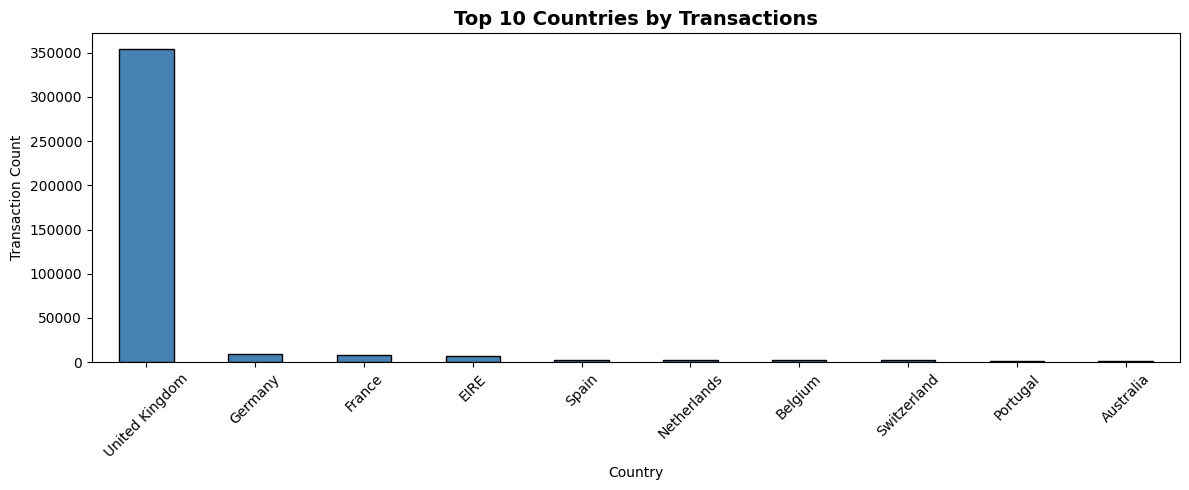

Country
United Kingdom    354321
Germany             9040
France              8341
EIRE                7236
Spain               2484
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1462
Australia           1182
Name: count, dtype: int64

TOP 10 BEST SELLING PRODUCTS


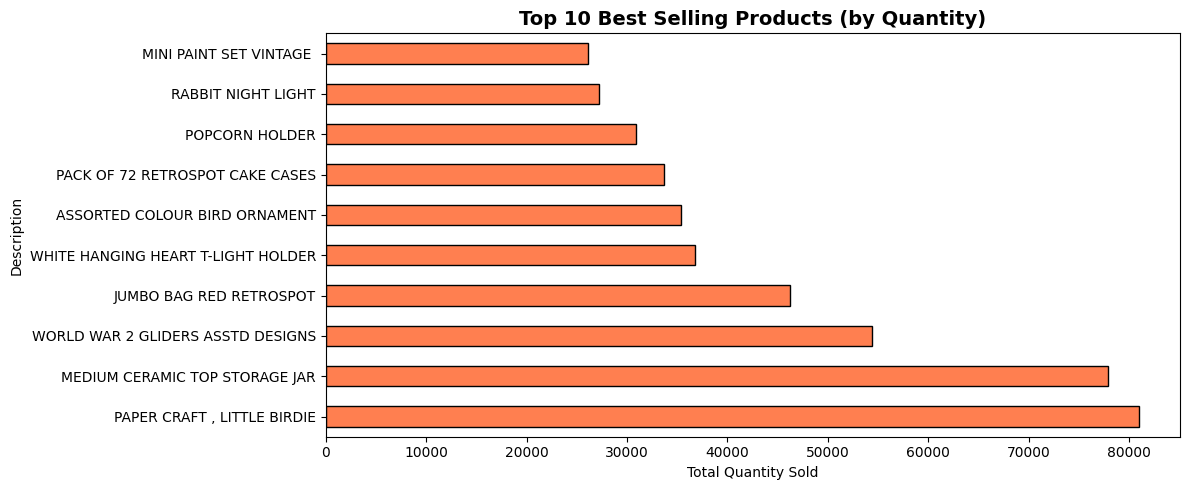


MONTHLY REVENUE TREND


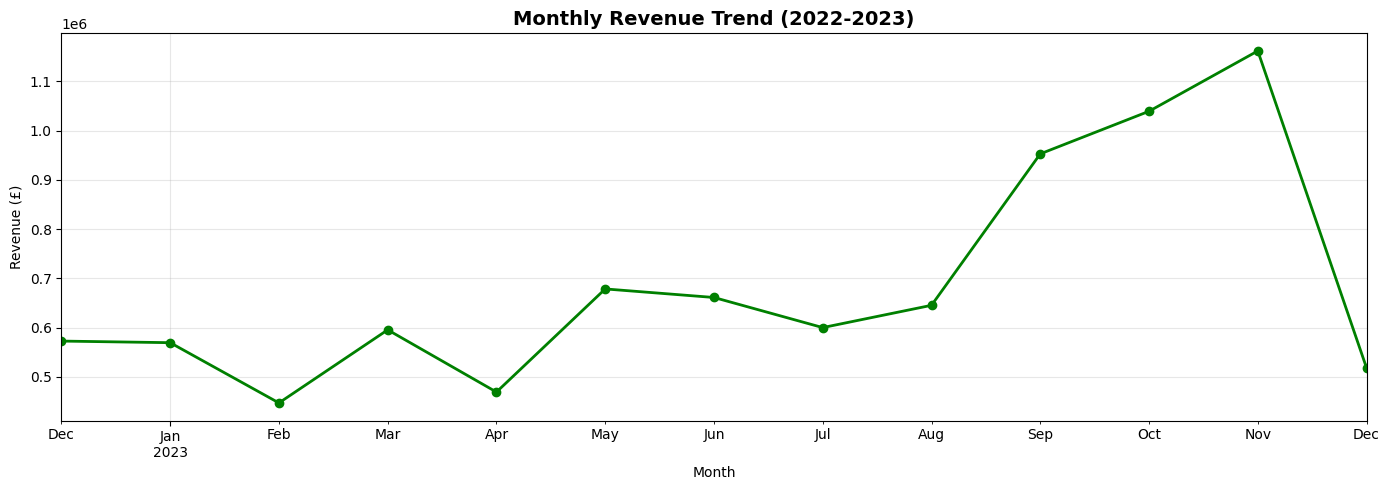


TRANSACTION AMOUNT DISTRIBUTION


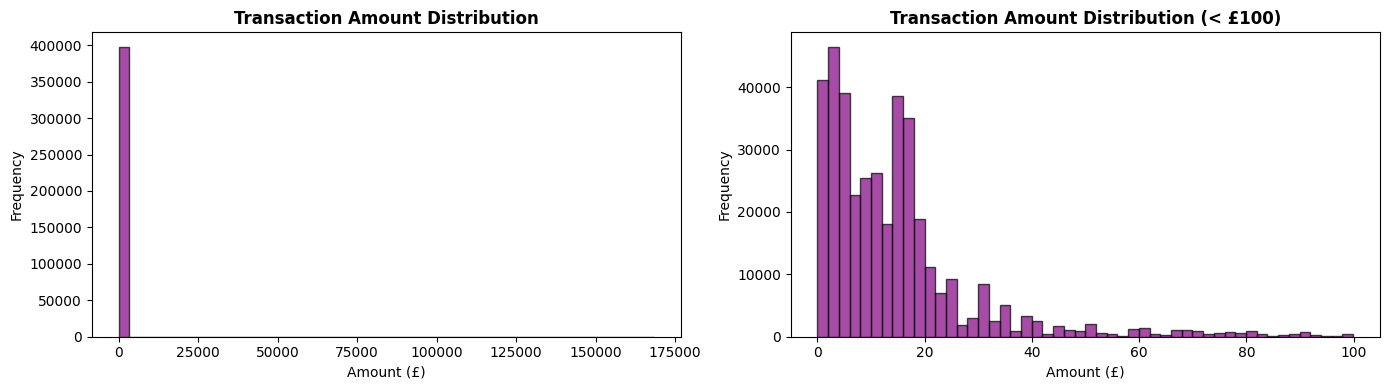


Transaction amount statistics:
count    397884.000000
mean         22.397000
std         309.071041
min           0.001000
25%           4.680000
50%          11.800000
75%          19.800000
max      168469.600000
Name: TotalAmount, dtype: float64

DATA OVERVIEW
Total Transactions: 397,884
Unique Customers: 4,338
Unique Products: 3,877
Countries: 37
Date Range: 2022-12-01 08:26:00 to 2023-12-09 12:50:00


In [3]:
# ============================================
# BLOCK 3: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

# 1. Top 10 countries by transaction volume
print("=" * 50)
print("TOP 10 COUNTRIES BY TRANSACTIONS")
print("=" * 50)
plt.figure(figsize=(12, 5))
df['Country'].value_counts().head(10).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 10 Countries by Transactions', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Transaction Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../assets/eda_countries.png', dpi=300, bbox_inches='tight')
plt.show()
print(df['Country'].value_counts().head(10))

# 2. Top 10 products by quantity sold
print("\n" + "=" * 50)
print("TOP 10 BEST SELLING PRODUCTS")
print("=" * 50)
plt.figure(figsize=(12, 5))
df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10).plot(
    kind='barh', color='coral', edgecolor='black')
plt.title('Top 10 Best Selling Products (by Quantity)', fontsize=14, fontweight='bold')
plt.xlabel('Total Quantity Sold')
plt.tight_layout()
plt.savefig('../assets/eda_products.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Monthly revenue trend
print("\n" + "=" * 50)
print("MONTHLY REVENUE TREND")
print("=" * 50)
monthly_revenue = df.set_index('InvoiceDate')['TotalAmount'].resample('M').sum()
plt.figure(figsize=(14, 5))
monthly_revenue.plot(color='green', linewidth=2, marker='o')
plt.title('Monthly Revenue Trend (2022-2023)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../assets/eda_trend.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Transaction amount distribution
print("\n" + "=" * 50)
print("TRANSACTION AMOUNT DISTRIBUTION")
print("=" * 50)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['TotalAmount'], bins=50, color='purple', edgecolor='black', alpha=0.7)
axes[0].set_title('Transaction Amount Distribution', fontweight='bold')
axes[0].set_xlabel('Amount (£)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df[df['TotalAmount'] < 100]['TotalAmount'], bins=50, color='purple', 
             edgecolor='black', alpha=0.7)
axes[1].set_title('Transaction Amount Distribution (< £100)', fontweight='bold')
axes[1].set_xlabel('Amount (£)')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('../assets/eda_amount_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTransaction amount statistics:")
print(df['TotalAmount'].describe())

# 5. Unique customers and products
print("\n" + "=" * 50)
print("DATA OVERVIEW")
print("=" * 50)
print(f"Total Transactions: {len(df):,}")
print(f"Unique Customers: {df['CustomerID'].nunique():,}")
print(f"Unique Products: {df['Description'].nunique():,}")
print(f"Countries: {df['Country'].nunique():,}")
print(f"Date Range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")

Reference date: 2023-12-10 12:50:00

RFM SUMMARY STATISTICS
         CustomerID      Recency    Frequency       Monetary
count   4338.000000  4338.000000  4338.000000    4338.000000
mean   15300.408022    92.536422     4.272015    2054.266459
std     1721.808492   100.014169     7.697998    8989.230441
min    12346.000000     1.000000     1.000000       3.750000
25%    13813.250000    18.000000     1.000000     307.415000
50%    15299.500000    51.000000     2.000000     674.485000
75%    16778.750000   142.000000     5.000000    1661.740000
max    18287.000000   374.000000   209.000000  280206.020000

RFM SAMPLE DATA
   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40
5       12352       36          8   2506.04
6       12353      204          1     89.00
7       12354      232

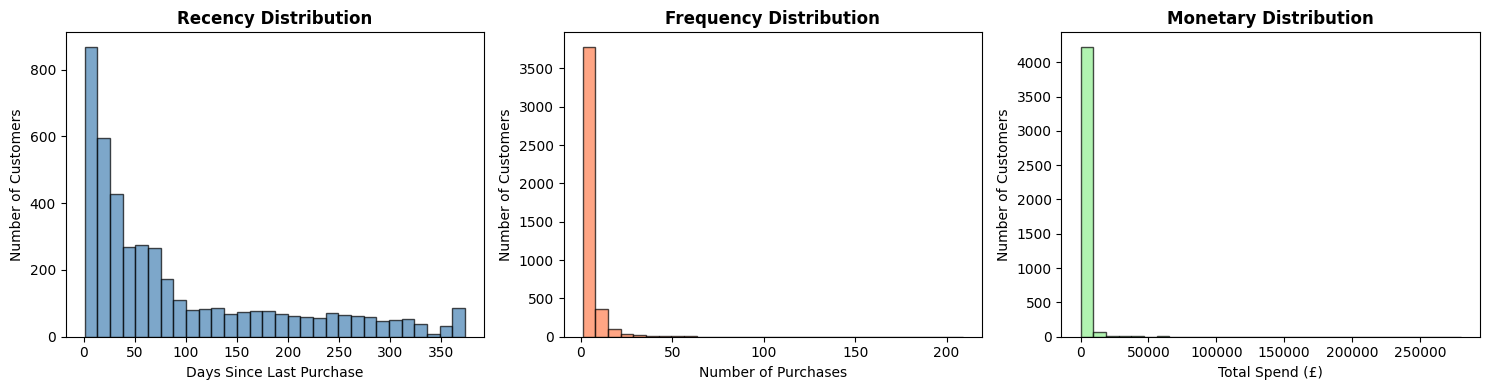


Box plots for outlier detection:


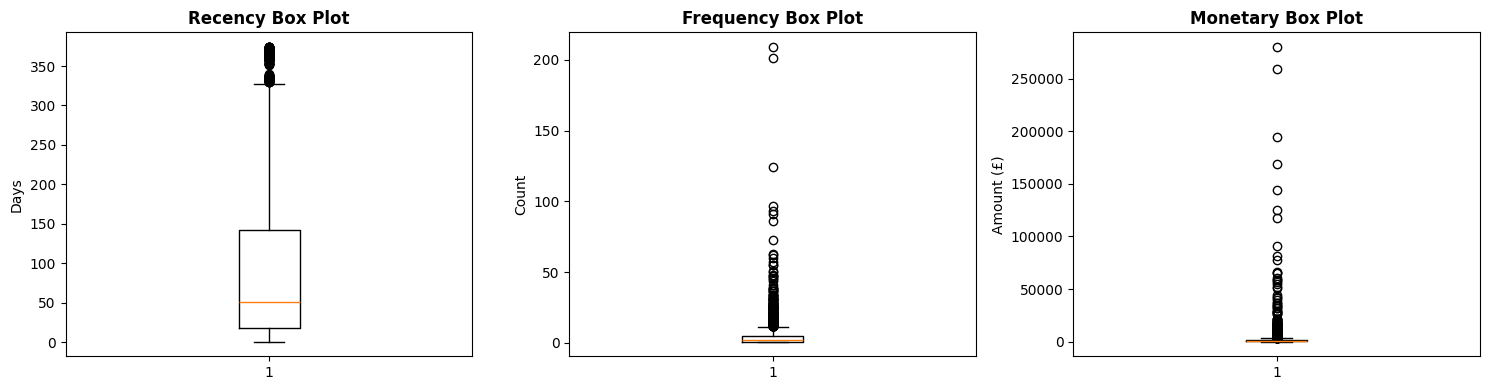


✅ RFM features created successfully!
Total customers: 4338

Recency - Min: 1, Max: 374
Frequency - Min: 1, Max: 209
Monetary - Min: £3.75, Max: £280206.02


In [4]:
# ============================================
# BLOCK 4: RFM FEATURE ENGINEERING
# ============================================

# Reference date = max date in dataset + 1 day
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date}")

# Calculate RFM metrics for each customer
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalAmount', 'sum')
).reset_index()

# Round monetary to 2 decimals
rfm['Monetary'] = rfm['Monetary'].round(2)

print("\n" + "=" * 50)
print("RFM SUMMARY STATISTICS")
print("=" * 50)
print(rfm.describe())

print("\n" + "=" * 50)
print("RFM SAMPLE DATA")
print("=" * 50)
print(rfm.head(10))

# RFM Distributions
print("\n" + "=" * 50)
print("RFM DISTRIBUTIONS")
print("=" * 50)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rfm['Recency'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Recency Distribution', fontweight='bold')
axes[0].set_xlabel('Days Since Last Purchase')
axes[0].set_ylabel('Number of Customers')

axes[1].hist(rfm['Frequency'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Frequency Distribution', fontweight='bold')
axes[1].set_xlabel('Number of Purchases')
axes[1].set_ylabel('Number of Customers')

axes[2].hist(rfm['Monetary'], bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[2].set_title('Monetary Distribution', fontweight='bold')
axes[2].set_xlabel('Total Spend (£)')
axes[2].set_ylabel('Number of Customers')

plt.tight_layout()
plt.savefig('../assets/rfm_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# Box plots for RFM
print("\nBox plots for outlier detection:")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].boxplot(rfm['Recency'])
axes[0].set_title('Recency Box Plot', fontweight='bold')
axes[0].set_ylabel('Days')

axes[1].boxplot(rfm['Frequency'])
axes[1].set_title('Frequency Box Plot', fontweight='bold')
axes[1].set_ylabel('Count')

axes[2].boxplot(rfm['Monetary'])
axes[2].set_title('Monetary Box Plot', fontweight='bold')
axes[2].set_ylabel('Amount (£)')

plt.tight_layout()
plt.savefig('../assets/rfm_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ RFM features created successfully!")
print(f"Total customers: {len(rfm)}")
print(f"\nRecency - Min: {rfm['Recency'].min()}, Max: {rfm['Recency'].max()}")
print(f"Frequency - Min: {rfm['Frequency'].min()}, Max: {rfm['Frequency'].max()}")
print(f"Monetary - Min: £{rfm['Monetary'].min():.2f}, Max: £{rfm['Monetary'].max():.2f}")

STEP 1: STANDARDIZING RFM VALUES
Scaled data shape: (4338, 3)

Scaled data statistics:
            Recency     Frequency      Monetary
count  4.338000e+03  4.338000e+03  4.338000e+03
mean   2.702618e-17  1.801745e-17  1.637950e-17
std    1.000115e+00  1.000115e+00  1.000115e+00
min   -9.153401e-01 -4.250965e-01 -2.281344e-01
25%   -7.453445e-01 -4.250965e-01 -1.943495e-01
50%   -4.153533e-01 -2.951776e-01 -1.535104e-01
75%    4.946227e-01  9.457903e-02 -4.367134e-02
max    2.814561e+00  2.659803e+01  3.094634e+01

STEP 2: ELBOW METHOD
k=2 → Inertia: 9012.64, Silhouette Score: 0.8958
k=3 → Inertia: 5439.30, Silhouette Score: 0.5942
k=4 → Inertia: 4092.14, Silhouette Score: 0.6162
k=5 → Inertia: 3118.28, Silhouette Score: 0.6165
k=6 → Inertia: 2472.57, Silhouette Score: 0.5963
k=7 → Inertia: 2022.41, Silhouette Score: 0.5165
k=8 → Inertia: 1715.81, Silhouette Score: 0.4859
k=9 → Inertia: 1445.63, Silhouette Score: 0.4777
k=10 → Inertia: 1303.39, Silhouette Score: 0.4271


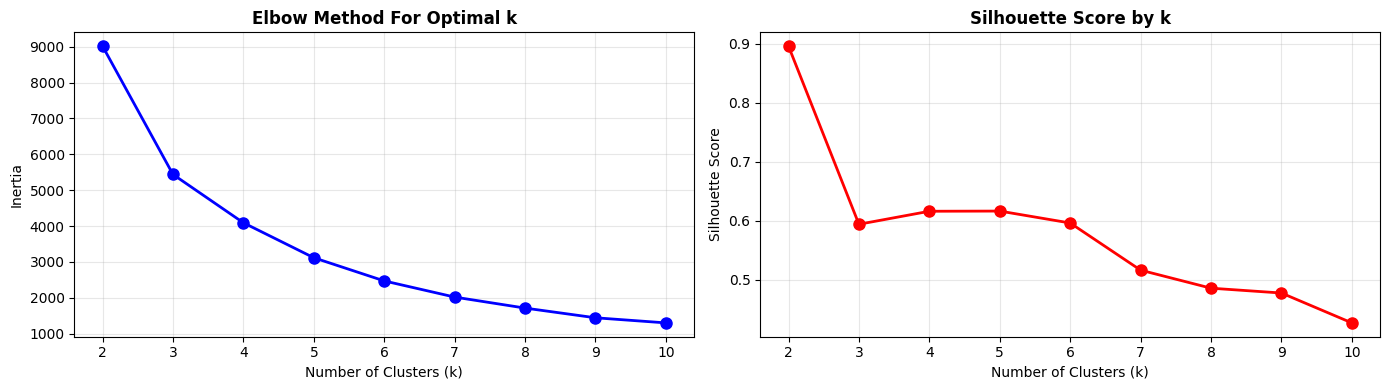


STEP 3: FINAL KMEANS CLUSTERING (k=4)
Cluster distribution:
Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64

STEP 4: CLUSTER CHARACTERISTICS

Cluster Summary (Mean & Median):
            Recency         Frequency              Monetary            
               mean median       mean median           mean      median
Cluster                                                                
0         43.702685   32.0   3.682711    3.0    1359.049283     829.295
1        248.075914  243.0   1.552015    1.0     480.617479     310.470
2          7.384615    2.0  82.538462   63.0  127338.313846  117379.630
3         15.500000    5.0  22.333333   19.0   12709.090490    8037.730


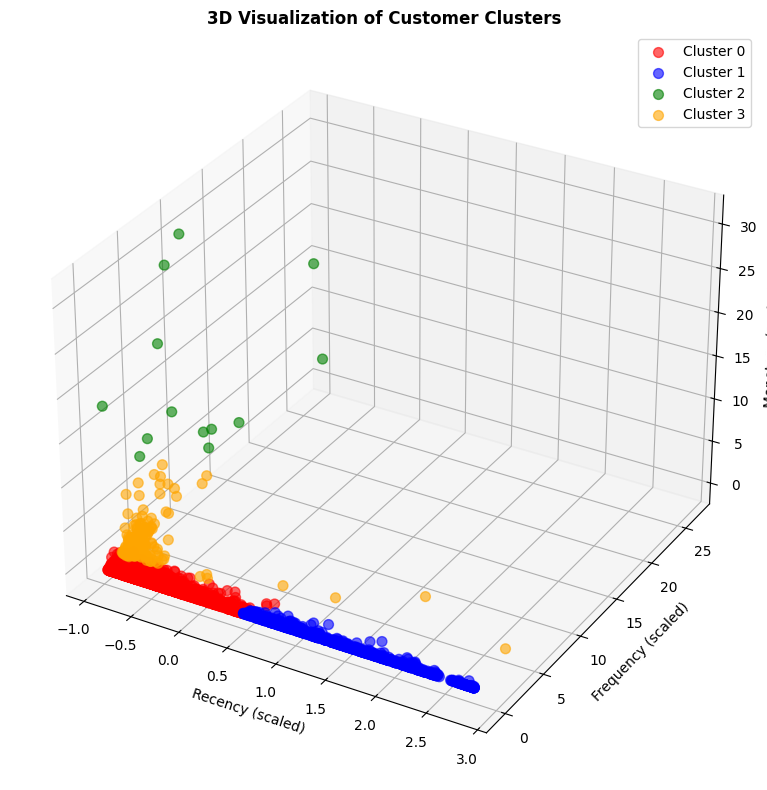


STEP 5: CLUSTER LABELING

Cluster Labels and Counts:
Segment
Regular       3054
High-Value    1067
Occasional     204
At-Risk         13
Name: count, dtype: int64

Segment Characteristics:

Regular (Cluster 0):
  Avg Recency: 43.7 days
  Avg Frequency: 3.7 purchases
  Avg Monetary: £1359.05

High-Value (Cluster 1):
  Avg Recency: 248.1 days
  Avg Frequency: 1.6 purchases
  Avg Monetary: £480.62

At-Risk (Cluster 2):
  Avg Recency: 7.4 days
  Avg Frequency: 82.5 purchases
  Avg Monetary: £127338.31

Occasional (Cluster 3):
  Avg Recency: 15.5 days
  Avg Frequency: 22.3 purchases
  Avg Monetary: £12709.09

STEP 6: SAVING MODELS
✅ KMeans model saved to: ../models/kmeans_model.pkl
✅ StandardScaler saved to: ../models/rfm_scaler.pkl
✅ RFM data with clusters saved to: ../models/rfm_with_clusters.csv


In [6]:
# ============================================
# BLOCK 5: CLUSTERING METHODOLOGY
# ============================================

# Step 1: Standardize/Normalize RFM values
print("=" * 50)
print("STEP 1: STANDARDIZING RFM VALUES")
print("=" * 50)

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

print("Scaled data shape:", rfm_scaled.shape)
print("\nScaled data statistics:")
print(rfm_scaled_df.describe())

# Step 2: Elbow Method to find optimal clusters
print("\n" + "=" * 50)
print("STEP 2: ELBOW METHOD")
print("=" * 50)

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)
    
    # Calculate silhouette score
    labels = kmeans.labels_
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k} → Inertia: {kmeans.inertia_:.2f}, Silhouette Score: {score:.4f}")

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method For Optimal k', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score by k', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../assets/elbow_silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

# Step 3: Fit final KMeans model with optimal k (k=4)
print("\n" + "=" * 50)
print("STEP 3: FINAL KMEANS CLUSTERING (k=4)")
print("=" * 50)

optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(f"Cluster distribution:")
print(rfm['Cluster'].value_counts().sort_index())

# Step 4: Analyze cluster characteristics
print("\n" + "=" * 50)
print("STEP 4: CLUSTER CHARACTERISTICS")
print("=" * 50)

cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].agg(['mean', 'median'])
print("\nCluster Summary (Mean & Median):")
print(cluster_summary)

# Visualize clusters in 3D
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

colors = ['red', 'blue', 'green', 'orange']
for cluster in range(optimal_k):
    cluster_data = rfm_scaled_df[rfm['Cluster'] == cluster]
    ax.scatter(cluster_data['Recency'], cluster_data['Frequency'], cluster_data['Monetary'],
               label=f'Cluster {cluster}', s=50, alpha=0.6, c=colors[cluster])

ax.set_xlabel('Recency (scaled)')
ax.set_ylabel('Frequency (scaled)')
ax.set_zlabel('Monetary (scaled)')
ax.set_title('3D Visualization of Customer Clusters', fontweight='bold', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('../assets/clusters_3d.png', dpi=300, bbox_inches='tight')
plt.show()

# Step 5: Label clusters based on RFM characteristics
print("\n" + "=" * 50)
print("STEP 5: CLUSTER LABELING")
print("=" * 50)

# Manually label clusters based on your output
# Check the cluster_summary above and adjust accordingly
cluster_labels = {
    0: 'Regular',
    1: 'High-Value',
    2: 'At-Risk',
    3: 'Occasional'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_labels)

print("\nCluster Labels and Counts:")
print(rfm['Segment'].value_counts())

print("\nSegment Characteristics:")
for cluster_id, label in cluster_labels.items():
    segment_data = rfm[rfm['Cluster'] == cluster_id][['Recency', 'Frequency', 'Monetary']].mean()
    print(f"\n{label} (Cluster {cluster_id}):")
    print(f"  Avg Recency: {segment_data['Recency']:.1f} days")
    print(f"  Avg Frequency: {segment_data['Frequency']:.1f} purchases")
    print(f"  Avg Monetary: £{segment_data['Monetary']:.2f}")

# Step 6: Save the trained model and scaler
print("\n" + "=" * 50)
print("STEP 6: SAVING MODELS")
print("=" * 50)

joblib.dump(kmeans, '../models/kmeans_model.pkl')
joblib.dump(scaler, '../models/rfm_scaler.pkl')

print("✅ KMeans model saved to: ../models/kmeans_model.pkl")
print("✅ StandardScaler saved to: ../models/rfm_scaler.pkl")

# Save RFM with clusters
rfm.to_csv('../models/rfm_with_clusters.csv', index=False)
print("✅ RFM data with clusters saved to: ../models/rfm_with_clusters.csv")

In [8]:
# ============================================
# BLOCK 6: PRODUCT RECOMMENDATION SYSTEM
# ============================================

print("=" * 50)
print("BUILDING ITEM-BASED COLLABORATIVE FILTERING")
print("=" * 50)

# Step 1: Create Customer-Product Matrix
print("\nStep 1: Creating Customer-Product Matrix...")
product_matrix = df.groupby(['CustomerID', 'Description'])['Quantity'].sum().unstack(fill_value=0)

print(f"Product matrix shape: {product_matrix.shape}")
print(f"Customers: {product_matrix.shape[0]}")
print(f"Products: {product_matrix.shape[1]}")
print(f"\nProduct matrix sample:")
print(product_matrix.iloc[:5, :5])

# Step 2: Calculate Cosine Similarity between products
print("\n" + "=" * 50)
print("Step 2: Calculating Cosine Similarity between Products...")
print("=" * 50)

product_similarity = cosine_similarity(product_matrix.T)
product_sim_df = pd.DataFrame(
    product_similarity,
    index=product_matrix.columns,
    columns=product_matrix.columns
)

print(f"Similarity matrix shape: {product_sim_df.shape}")
print(f"\nSample similarity scores for first product:")
first_product = product_sim_df.index[0]
print(f"Product: {first_product}")
print(product_sim_df[first_product].sort_values(ascending=False).head(10))

# Step 3: Create recommendation function
print("\n" + "=" * 50)
print("Step 3: Testing Recommendation Function")
print("=" * 50)

def get_recommendations(product_name, n=5):
    """
    Returns top N similar products based on cosine similarity
    """
    product_name = product_name.upper().strip()
    
    if product_name not in product_sim_df.index:
        return f"❌ Product '{product_name}' not found in database."
    
    # Get similarity scores for the product
    similar_products = product_sim_df[product_name].sort_values(ascending=False)
    
    # Exclude the product itself and return top N
    recommendations = similar_products[1:n+1].index.tolist()
    
    return recommendations

# Test the function with different products
test_products = [
    'WHITE HANGING HEART T-LIGHT HOLDER',
    'RED WOOLLY HOTTIE WHITE HEART',
    'JUMBO BAG RED RETROSPOT'
]

for test_product in test_products:
    print(f"\n📦 Product: {test_product}")
    print("Recommended products:")
    recommendations = get_recommendations(test_product, n=5)
    
    if isinstance(recommendations, str):
        print(recommendations)
    else:
        for i, rec in enumerate(recommendations, 1):
            similarity_score = product_sim_df.loc[test_product, rec]
            print(f"  {i}. {rec} (similarity: {similarity_score:.4f})")

# Step 4: Save similarity matrix for Streamlit app
print("\n" + "=" * 50)
print("Step 4: Saving Recommendation System")
print("=" * 50)

product_sim_df.to_csv('../models/product_similarity.csv')
print("✅ Product similarity matrix saved to: ../models/product_similarity.csv")

# Also save as pickle for faster loading
joblib.dump(product_sim_df, '../models/product_similarity.pkl')
print("✅ Product similarity matrix (pickle) saved to: ../models/product_similarity.pkl")

# Save list of all products for Streamlit autocomplete
all_products = sorted(product_matrix.columns.tolist())
joblib.dump(all_products, '../models/all_products.pkl')
print("✅ Product list saved to: ../models/all_products.pkl")

# Create a reference guide of top products
print("\n" + "=" * 50)
print("Top 20 Most Purchased Products")
print("=" * 50)

top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(20)
for i, (product, qty) in enumerate(top_products.items(), 1):
    print(f"{i}. {product} - {int(qty)} units")

print("\n✅ Recommendation system built successfully!")

BUILDING ITEM-BASED COLLABORATIVE FILTERING

Step 1: Creating Customer-Product Matrix...
Product matrix shape: (4338, 3877)
Customers: 4338
Products: 3877

Product matrix sample:
Description   4 PURPLE FLOCK DINNER CANDLES   50'S CHRISTMAS GIFT BAG LARGE  \
CustomerID                                                                    
12346                                     0                               0   
12347                                     0                               0   
12348                                     0                               0   
12349                                     0                               0   
12350                                     0                               0   

Description   DOLLY GIRL BEAKER   I LOVE LONDON MINI BACKPACK  \
CustomerID                                                      
12346                         0                             0   
12347                         0                             0   
12348  